## HW 3 - Scraping and Regression

#### Linear Regressions exploring Hacker Rank
We will consider which columns in hn_stories.csv are the best candidates for influencing rank. 

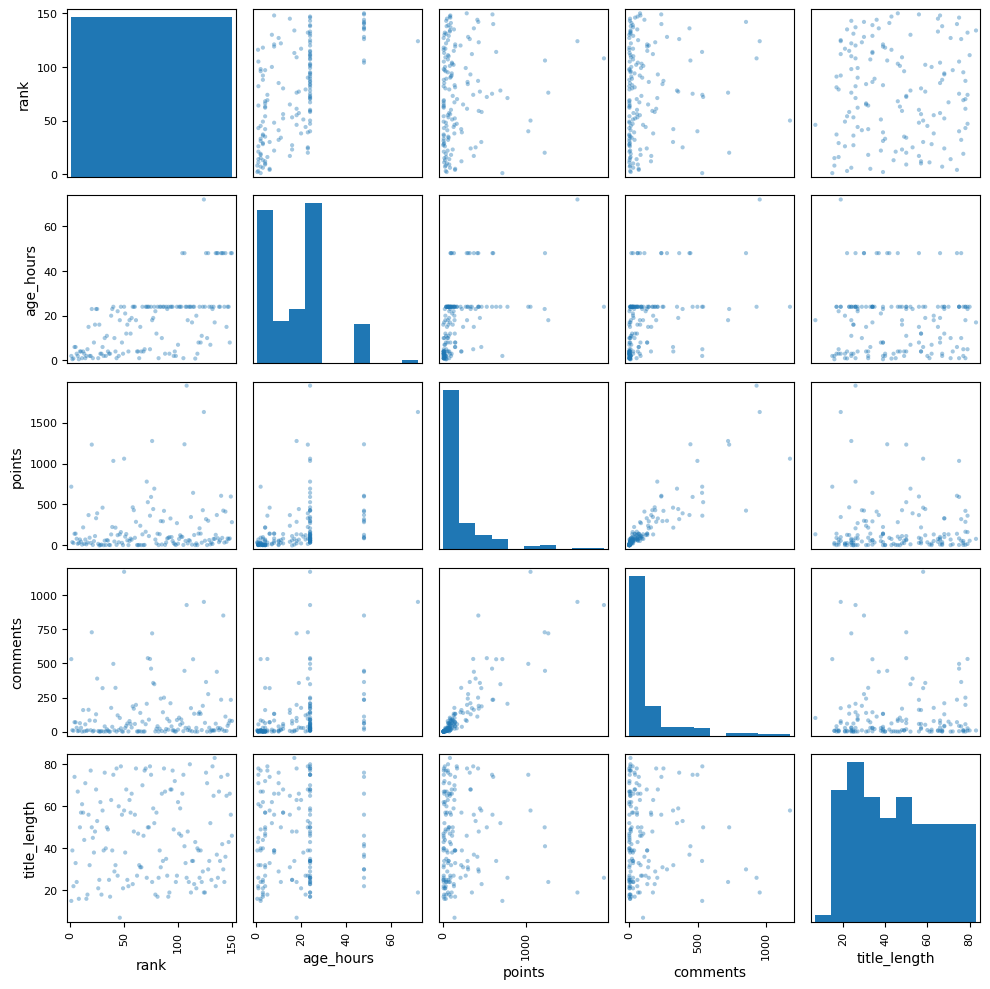

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

hnDFRaw = pd.read_csv("hn_stories.csv")

#I'm going to assume that story_id is an arbitrary number with no effect
cols = ['rank', 'age_hours', 'points', 'comments', 'title_length']

# Option A: pandas built-in (quick)
pd.plotting.scatter_matrix(hnDFRaw[cols], figsize=(10, 10), alpha=0.4)
plt.tight_layout()
plt.show()

This data isn't giving us a very clear picture. Some obsersations:
- title_length and rank seem uncorrelated, which fits my expectation. My assumption was title_length shouldn't matter.
- the points and comments graphs are similar, both showing clumps of data points near 0 for all rank values. So all rows with close to 0 points and comments are still represented across all ranks. 
- rank vs age_hours has a more noticeable trend where more recent stories are more represented at the top ranks and there is some clumping around 25 and 50 hours that may represent a significant effect.

But, onto the regressions. I will look at points, points + comments, inverse points, and inverse hours.

In [14]:
import statsmodels.formula.api as smf

# The formula string: "outcome ~ predictor1 + predictor2"
# Left of ~ = what you're predicting
# Right of ~ = your predictors

# Regression 1: rank ~ points (simple)
model1 = smf.ols("rank ~ points", data=hnDFRaw).fit()
print(model1.summary())

# Regression 2: rank ~ points + comments (multiple)
model2 = smf.ols("rank ~ points + comments", data=hnDFRaw).fit()
print(model2.summary())

# Regression 3: inverse linear — rank ~ 1/points
hnDFRaw['inv_points'] = 1 / (hnDFRaw['points'] + 1)  # +1 avoids division by zero
model3 = smf.ols("rank ~ inv_points", data=hnDFRaw).fit()
print(model3.summary())

# Regression 4: inverse linear — rank ~ 1/age_hours
hnDFRaw['inv_age'] = 1 / (hnDFRaw['age_hours'] + 1)  # +1 avoids division by zero
model4 = smf.ols("rank ~ inv_age", data=hnDFRaw).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.050
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.307
Time:                        23:14:23   Log-Likelihood:                -777.53
No. Observations:                 150   AIC:                             1559.
Df Residuals:                     148   BIC:                             1565.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     73.1775      4.209     17.387      0.0

#### Plotting the Regressions

For models 1, 3, and 4.

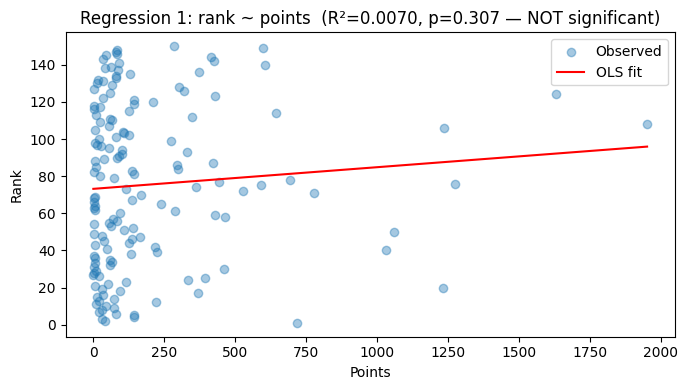

In [16]:
import numpy as np

# Plot: rank ~ points
pts_range = np.linspace(hnDFRaw['points'].min(), hnDFRaw['points'].max(), 200)
predicted = model1.params['Intercept'] + model1.params['points'] * pts_range

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(hnDFRaw['points'], hnDFRaw['rank'], alpha=0.4, label='Observed')
ax.plot(pts_range, predicted, color='red', label='OLS fit')
ax.set_xlabel('Points'); ax.set_ylabel('Rank')
ax.set_title('Regression 1: rank ~ points  (R²=0.0070, p=0.307 — NOT significant)')
ax.legend()
plt.tight_layout()
plt.show()

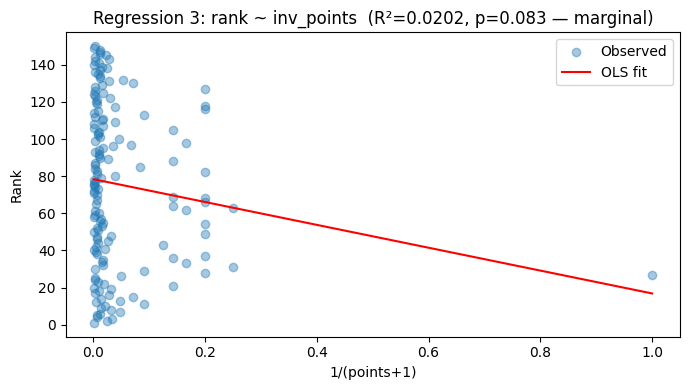

In [17]:
# Plot: rank ~ inv_points
inv_range = np.linspace(hnDFRaw['inv_points'].min(), hnDFRaw['inv_points'].max(), 200)
predicted = model3.params['Intercept'] + model3.params['inv_points'] * inv_range

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(hnDFRaw['inv_points'], hnDFRaw['rank'], alpha=0.4, label='Observed')
ax.plot(inv_range, predicted, color='red', label='OLS fit')
ax.set_xlabel('1/(points+1)'); ax.set_ylabel('Rank')
ax.set_title('Regression 3: rank ~ inv_points  (R²=0.0202, p=0.083 — marginal)')
ax.legend()
plt.tight_layout()
plt.show()

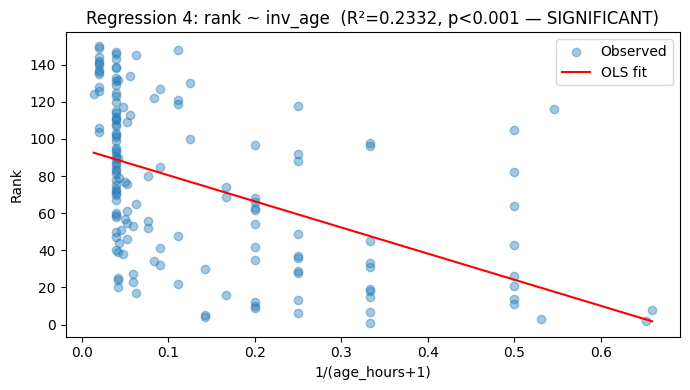

In [18]:
# Plot: rank ~ inv_age
inv_age_range = np.linspace(hnDFRaw['inv_age'].min(), hnDFRaw['inv_age'].max(), 200)
predicted = model4.params['Intercept'] + model4.params['inv_age'] * inv_age_range

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(hnDFRaw['inv_age'], hnDFRaw['rank'], alpha=0.4, label='Observed')
ax.plot(inv_age_range, predicted, color='red', label='OLS fit')
ax.set_xlabel('1/(age_hours+1)'); ax.set_ylabel('Rank')
ax.set_title('Regression 4: rank ~ inv_age  (R²=0.2332, p<0.001 — SIGNIFICANT)')
ax.legend()
plt.tight_layout()
plt.show()

## Regression Comparison
| Model | Formula | R² | p-value | Significant? |
|-------|---------|-----|---------|-------------|
| 1 | rank ~ points | 0.0070 | 0.307 | No |
| 2 | rank ~ points + comments | 0.0071 | 0.594 | No |
| 3 | rank ~ inv_points | 0.0202 | 0.083 | ~still not great |
| 4 | rank ~ inv_age | 0.2332 | <0.001 | Yes |

**Observations**
- The most significant relationship we found was the inverse relationship between rank and age, with a low P-value and a non-disqualifying R^2 value. As stories in our data set get older they are less present in the lowest rankings.
- 'points' and 'points + comments' gave us insignificant results.

## Logistic Regression (Front Page)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Step 1: create binary target
hnDFRaw['front_page'] = (hnDFRaw['source_page'] == 1).astype(int)
print('Front page counts:', hnDFRaw['front_page'].value_counts().to_dict())

# Step 2: select features and scale
features = ['points', 'comments', 'age_hours', 'title_length']
X = hnDFRaw[features]
y = hnDFRaw['front_page']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: fit logistic regression
lr_model = LogisticRegression()
lr_model.fit(X_scaled, y)

print('Accuracy (train):', round(lr_model.score(X_scaled, y), 4))
print('\nCoefficients (standardized):')
for feat, coef in zip(features, lr_model.coef_[0]):
    direction = 'INCREASES' if coef > 0 else 'DECREASES'
    print(f'  {feat:15s}: {coef:+.4f}  -> {direction} front-page probability')

Front page counts: {0: 120, 1: 30}
Accuracy (train): 0.8067

Coefficients (standardized):
  points         : +0.4827  -> INCREASES front-page probability
  comments       : -0.0269  -> DECREASES front-page probability
  age_hours      : -1.8485  -> DECREASES front-page probability
  title_length   : -0.0401  -> DECREASES front-page probability


Our model has detected two meaningful effects:
- points increase front-page probability
- age_hours decrease front-page probability

The age_hours finding is in line with the linear regression relationship we had detected earlier (though we had expressed it as an inverse relationship beforehand.)

Earlier, we had disregarded the points relationship because of its low p-value. Looking at it in this context...

In [21]:
import statsmodels.formula.api as smf

logit_model = smf.logit("front_page ~ points + comments + age_hours + title_length", data=hnDFRaw).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.373867
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             front_page   No. Observations:                  150
Model:                          Logit   Df Residuals:                      145
Method:                           MLE   Df Model:                            4
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                  0.2529
Time:                        23:48:28   Log-Likelihood:                -56.080
converged:                       True   LL-Null:                       -75.060
Covariance Type:            nonrobust   LLR p-value:                 1.142e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1536      0.614      0.250      0.802      -1.049       1.357
points           0.0027

...we see that is still the case. `age_hours` remains our most reliable relationship.

/Users/jonapulse/WorkSpace/MSD/Summer2026/CS6017/Week3/HW3/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


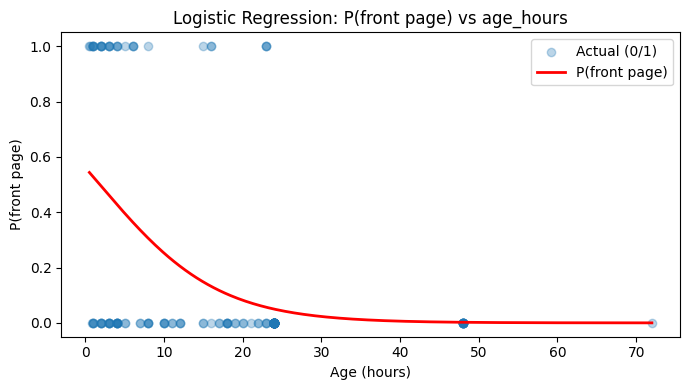

In [22]:
# Plot P(front_page) vs age_hours
# Hold other features at their mean, vary age_hours across its range
means = hnDFRaw[features].mean()
age_range = np.linspace(hnDFRaw['age_hours'].min(), hnDFRaw['age_hours'].max(), 300)

X_plot = np.column_stack([
    np.full(300, means['points']),
    np.full(300, means['comments']),
    age_range,
    np.full(300, means['title_length'])
])
X_plot_scaled = scaler.transform(X_plot)
probs = lr_model.predict_proba(X_plot_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(hnDFRaw['age_hours'], hnDFRaw['front_page'], alpha=0.3, label='Actual (0/1)')
ax.plot(age_range, probs, color='red', linewidth=2, label='P(front page)')
ax.set_xlabel('Age (hours)')
ax.set_ylabel('P(front page)')
ax.set_title('Logistic Regression: P(front page) vs age_hours')
ax.legend()
plt.tight_layout()
plt.show()

### What does our Logistic regression tell us?

**Accuracy:** ~80.7%: Well this isn't bad, because 80% of our data is 'not front page', we could also have arrived at this accuracy by just guessing everything isn't on the front page. Not great.

**Coefficients:**

| Feature | Coefficient |
|---------|-------------|
| age_hours | **-1.85** | 
| points | +0.48 |
| title_length | -0.04 | 
| comments | -0.03 | 

`age_hours` is our strongest driver, followed by `points`.

If we compare this to the HackerNew's outdated ranking formula...

$Score = \frac{P - 1}{(T + 2)^G}$

We can see our time relationship, as well as a modest effect from points. 